<a href="https://colab.research.google.com/github/RithwikRajSuram/Public-Health-Trends-Analysis-based-on-Tobacco-Use-and-Mortality-Patterns/blob/main/public_health_tobacco_mortality_analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
behavioral_risk_df = pd.read_csv('/content/Behavioral_Risk_Factor_Data__Tobacco_Use.csv')
behavioral_risk_df

,YEAR,LocationAbbr,LocationDesc,TopicType,TopicDesc,MeasureDesc,DataSource,Response,Data_Value_Unit,Data_Value_Type,...,GeoLocation,TopicTypeId,TopicId,MeasureId,StratificationID1,StratificationID2,StratificationID3,StratificationID4,SubMeasureID,DisplayOrder
0,2017,GU,Guam,Tobacco Use – Survey Data,Cigarette Use (Adults),Current Smoking,BRFSS,NaN,%,Percentage,...,"(13.444304, 144.793731)",BEH,100BEH,110CSA,2GEN,8AGE,6RAC,6EDU,BRF21,21
1,2018,US,National Median (States and DC),Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Status,BRFSS,Current,%,Percentage,...,NaN,BEH,100BEH,165SSA,1GEN,8AGE,6RAC,6EDU,BRF27,27
2,2017,US,National Median (States and DC),Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Status,BRFSS,Never,%,Percentage,...,NaN,BEH,100BEH,165SSA,1GEN,8AGE,6RAC,6EDU,BRF28,28
3,2016,GU,Guam,Tobacco Use – Survey Data,Smokeless Tobacco Use (Adults),Current Use,BRFSS,NaN,%,Percentage,...,"(13.444304, 144.793731)",BEH,150BEH,177SCU,1GEN,8AGE,4RAC,6EDU,BRF69,69
4,2014,GU,Guam,Tobacco Use – Survey Data,Cigarette Use (Adults),Current Smoking,BRFSS,NaN,%,Percentage,...,"(13.444304, 144.793731)",BEH,100BEH,110CSA,1GEN,8AGE,5RAC,6EDU,BRF22,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43336,2011,RI,Rhode Island,Tobacco Use – Survey Data,Smokeless Tobacco Use (Adults),Current Use,BRFSS,NaN,%,Percentage,...,"(41.70828019300046, -71.52247031399963)",BEH,150BEH,177SCU,1GEN,4AGE,6RAC,6EDU,BRF70,70
43337,2013-2014,MA,Massachusetts,Tobacco Use – Survey Data,Cigarette Use (Adults),Current Smoking – (2 yrs – Race/Ethnicity),BRFSS,NaN,%,Percentage,...,"(42.27687047000046, -72.08269067499964)",BEH,100BEH,112CS2,1GEN,8AGE,3RAC,6EDU,BRF32,32
43338,2015,AK,Alaska,Tobacco Use – Survey Data,Cigarette Use (Adults),Current Smoking,BRFSS,NaN,%,Percentage,...,"(64.84507995700051, -147.72205903599973)",BEH,100BEH,110CSA,1GEN,6AGE,6RAC,4EDU,BRF24,24
43339,2014,IA,Iowa,Tobacco Use – Survey Data,Smokeless Tobacco Use (Adults),User Status,BRFSS,Current,%,Percentage,...,"(42.46940091300047, -93.81649055599968)",BEH,150BEH,179SUS,2GEN,8AGE,6RAC,6EDU,BRF80,80


In [21]:
columns_to_drop = ['Data_Value_Unit', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote', 'GeoLocation']
behavioral_risk_df1 = behavioral_risk_df.drop(columns=[col for col in columns_to_drop if col in behavioral_risk_df.columns])
behavioral_risk_df1.columns.tolist()

['YEAR',
 'LocationAbbr',
 'LocationDesc',
 'TopicType',
 'TopicDesc',
 'MeasureDesc',
 'DataSource',
 'Response',
 'Data_Value_Type',
 'Data_Value',
 'Data_Value_Std_Err',
 'Low_Confidence_Limit',
 'High_Confidence_Limit',
 'Sample_Size',
 'Gender',
 'Race',
 'Age',
 'Education',
 'TopicTypeId',
 'TopicId',
 'MeasureId',
 'StratificationID1',
 'StratificationID2',
 'StratificationID3',
 'StratificationID4',
 'SubMeasureID',
 'DisplayOrder']

In [22]:
behavioral_risk_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43341 entries, 0 to 43340
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   YEAR                   43341 non-null  object 
 1   LocationAbbr           43341 non-null  object 
 2   LocationDesc           43341 non-null  object 
 3   TopicType              43341 non-null  object 
 4   TopicDesc              43341 non-null  object 
 5   MeasureDesc            43341 non-null  object 
 6   DataSource             43341 non-null  object 
 7   Response               15018 non-null  object 
 8   Data_Value_Type        43341 non-null  object 
 9   Data_Value             41224 non-null  float64
 10  Data_Value_Std_Err     41146 non-null  float64
 11  Low_Confidence_Limit   41146 non-null  float64
 12  High_Confidence_Limit  41146 non-null  float64
 13  Sample_Size            41146 non-null  float64
 14  Gender                 43341 non-null  object 
 15  Ra

In [23]:
behavioral_risk_df1['YEAR'] = pd.to_datetime(behavioral_risk_df1['YEAR'], format='%Y', errors='coerce')
behavioral_risk_df1['LocationDesc'] = behavioral_risk_df1['LocationDesc'].astype('category')
behavioral_risk_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43341 entries, 0 to 43340
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   YEAR                   38671 non-null  datetime64[ns]
 1   LocationAbbr           43341 non-null  object        
 2   LocationDesc           43341 non-null  category      
 3   TopicType              43341 non-null  object        
 4   TopicDesc              43341 non-null  object        
 5   MeasureDesc            43341 non-null  object        
 6   DataSource             43341 non-null  object        
 7   Response               15018 non-null  object        
 8   Data_Value_Type        43341 non-null  object        
 9   Data_Value             41224 non-null  float64       
 10  Data_Value_Std_Err     41146 non-null  float64       
 11  Low_Confidence_Limit   41146 non-null  float64       
 12  High_Confidence_Limit  41146 non-null  float64       
 13  S

In [24]:
behavioral_risk_df1.isna().sum()

,0
YEAR,4670
LocationAbbr,0
LocationDesc,0
TopicType,0
TopicDesc,0
MeasureDesc,0
DataSource,0
Response,28323
Data_Value_Type,0
Data_Value,2117


In [25]:
mode_values = behavioral_risk_df1.mode().iloc[0]
behavioral_risk_df1.fillna(mode_values, inplace=True)
behavioral_risk_df1.isna().sum()

,0
YEAR,0
LocationAbbr,0
LocationDesc,0
TopicType,0
TopicDesc,0
MeasureDesc,0
DataSource,0
Response,0
Data_Value_Type,0
Data_Value,0


In [26]:
behavioral_risk_df1.rename(columns={
    'LocationDesc': 'Location',
    'Data_Value': 'Tobacco_Use_Rate',
    'Low_Confidence_Limit': 'CI_Lower',
    'High_Confidence_Limit': 'CI_Upper',
    'YEAR': 'Year'
}, inplace=True)

behavioral_risk_df1.columns

Index(['Year', 'LocationAbbr', 'Location', 'TopicType', 'TopicDesc',
       'MeasureDesc', 'DataSource', 'Response', 'Data_Value_Type',
       'Tobacco_Use_Rate', 'Data_Value_Std_Err', 'CI_Lower', 'CI_Upper',
       'Sample_Size', 'Gender', 'Race', 'Age', 'Education', 'TopicTypeId',
       'TopicId', 'MeasureId', 'StratificationID1', 'StratificationID2',
       'StratificationID3', 'StratificationID4', 'SubMeasureID',
       'DisplayOrder'],
      dtype='object')

In [27]:
behavioral_risk_df1['Percent_Sample_Tobacco_Use'] = (behavioral_risk_df1['Tobacco_Use_Rate'] / behavioral_risk_df1['Sample_Size']) * 100
behavioral_risk_df1.head()
print(behavioral_risk_df1[['Tobacco_Use_Rate', 'Sample_Size','Percent_Sample_Tobacco_Use']].head())

   Tobacco_Use_Rate  Sample_Size  Percent_Sample_Tobacco_Use
0              30.0        692.0                    4.335260
1              16.1         56.0                   28.750000
2              58.2         56.0                  103.928571
3               0.5        123.0                    0.406504
4              21.9        209.0                   10.478469


In [28]:
num_duplicates = behavioral_risk_df.duplicated().sum()
num_duplicates

np.int64(0)

In [29]:
Q1 = behavioral_risk_df1['Year'].quantile(0.25)
Q3 = behavioral_risk_df1['Year'].quantile(0.75)
IQR = Q3-Q1
outlier = ((behavioral_risk_df1['Year'] < (Q1 - 1.5 * IQR)) | (behavioral_risk_df1['Year'] > (Q3 + 1.5 * IQR)))
outlier

,Year
0,False
1,False
2,False
3,False
4,False
...,...
43336,False
43337,False
43338,False
43339,False


In [30]:
behavioral_risk_df1['Sample_Size'] = pd.to_numeric(behavioral_risk_df1['Sample_Size'], errors='coerce')
Q1 = behavioral_risk_df1['Sample_Size'].quantile(0.25)
Q3 = behavioral_risk_df1['Sample_Size'].quantile(0.75)
IQR = Q3 - Q1
outlier = ((behavioral_risk_df1['Sample_Size'] < (Q1 - 1.5 * IQR)) |
           (behavioral_risk_df1['Sample_Size'] > (Q3 + 1.5 * IQR)))
outlier

,Sample_Size
0,False
1,False
2,False
3,False
4,False
...,...
43336,False
43337,False
43338,False
43339,False


In [31]:
Q1 = behavioral_risk_df1['Data_Value_Std_Err'].quantile(0.25)
Q3 = behavioral_risk_df1['Data_Value_Std_Err'].quantile(0.75)
IQR = Q3-Q1
outlier = ((behavioral_risk_df1['Data_Value_Std_Err'] < (Q1 - 1.5 * IQR)) | (behavioral_risk_df1['Data_Value_Std_Err'] > (Q3 + 1.5 * IQR)))
outlier

,Data_Value_Std_Err
0,False
1,False
2,False
3,False
4,True
...,...
43336,False
43337,False
43338,False
43339,False


In [32]:
columns_to_check = ['Data_Value_Std_Err']
for column in columns_to_check:
    data = behavioral_risk_df1[column]
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (data < lower_bound) | (data > upper_bound)
    num_outliers = outliers.sum()
    print(f"Number of outliers in {column}: {num_outliers}")

Number of outliers in Data_Value_Std_Err: 3307


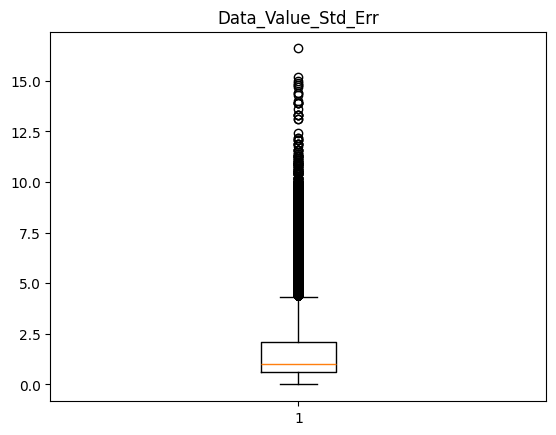

In [33]:
import matplotlib.pyplot as plt

plt.boxplot(behavioral_risk_df1['Data_Value_Std_Err'])
plt.title("Data_Value_Std_Err")
plt.show()

In [34]:
trimmed_data = behavioral_risk_df1[(behavioral_risk_df1['Data_Value_Std_Err'] >= lower_bound) & (behavioral_risk_df1['Data_Value_Std_Err'] <= upper_bound)]

In [35]:
Q1 = behavioral_risk_df1['Data_Value_Std_Err'].quantile(0.25)
Q3 = behavioral_risk_df1['Data_Value_Std_Err'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the trimmed data to find outliers
outliers_trimmed = trimmed_data[(trimmed_data['Data_Value_Std_Err'] < lower_bound) |
                                (trimmed_data['Data_Value_Std_Err'] > upper_bound)]

# Get the number of outliers in the trimmed data
num_outliers_trimmed = outliers_trimmed.shape[0]
print(f"Number of outliers in trimmed data: {num_outliers_trimmed}")

Number of outliers in trimmed data: 0


In [36]:
trimmed_data.to_csv('behavioral_risk_df1.csv', index=True)

In [37]:
from google.colab import files

trimmed_data.to_csv('behavioral_risk_df1.csv', index=True)

files.download('behavioral_risk_df1.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
Provisional_Counts_df = pd.read_csv('/content/Monthly_Provisional_Counts_of_Deaths_2020-2023.csv')
Provisional_Counts_df

,Data As Of,Start Date,End Date,Jurisdiction of Occurrence,Year,Month,All Cause,Natural Cause,Septicemia,Malignant Neoplasms,...,Intentional Self-Harm (Suicide),Assault (Homicide),Drug Overdose,COVID-19 (Multiple Cause of Death),COVID-19 (Underlying Cause of Death),flag_accid,flag_mva,flag_suic,flag_homic,flag_drugod
0,09/27/2023,01/01/2020,01/31/2020,United States,2020,1,264681,242914,3687,52635,...,4040.0,1708.0,6547.0,6,4,NaN,NaN,NaN,NaN,NaN
1,09/27/2023,02/01/2020,02/29/2020,United States,2020,2,244966,224343,3324,48764,...,3672.0,1471.0,6435.0,25,20,NaN,NaN,NaN,NaN,NaN
2,09/27/2023,03/01/2020,03/31/2020,United States,2020,3,269806,247634,3669,51640,...,3952.0,1693.0,7268.0,7175,6785,NaN,NaN,NaN,NaN,NaN
3,09/27/2023,04/01/2020,04/30/2020,United States,2020,4,322424,300780,3366,48773,...,3480.0,1756.0,7938.0,65553,62014,NaN,NaN,NaN,NaN,NaN
4,09/27/2023,05/01/2020,05/31/2020,United States,2020,5,280564,255489,3085,49012,...,3769.0,2067.0,9466.0,38330,35279,NaN,NaN,NaN,NaN,NaN
5,09/27/2023,06/01/2020,06/30/2020,United States,2020,6,250456,225455,3036,47962,...,3985.0,2261.0,8212.0,18026,15827,NaN,NaN,NaN,NaN,NaN
6,09/27/2023,07/01/2020,07/31/2020,United States,2020,7,279012,252481,3127,50626,...,4184.0,2426.0,8583.0,31135,28279,NaN,NaN,NaN,NaN,NaN
7,09/27/2023,08/01/2020,08/31/2020,United States,2020,8,277282,251071,3268,51209,...,4055.0,2348.0,8351.0,29913,27031,NaN,NaN,NaN,NaN,NaN
8,09/27/2023,09/01/2020,09/30/2020,United States,2020,9,257190,232827,3136,49671,...,3925.0,2191.0,7589.0,19158,16858,NaN,NaN,NaN,NaN,NaN
9,09/27/2023,10/01/2020,10/31/2020,United States,2020,10,273906,249366,3250,51255,...,3804.0,2368.0,7486.0,24930,22083,NaN,NaN,NaN,NaN,NaN


In [39]:
Provisional_Counts_df.shape

(45, 31)

In [40]:
Provisional_Counts_df.columns

Index(['Data As Of', 'Start Date', 'End Date', 'Jurisdiction of Occurrence',
       'Year', 'Month', 'All Cause', 'Natural Cause', 'Septicemia',
       'Malignant Neoplasms', 'Diabetes Mellitus', 'Alzheimer Disease',
       'Influenza and Pneumonia', 'Chronic Lower Respiratory Diseases',
       'Other Diseases of Respiratory System',
       'Nephritis, Nephrotic Syndrome and Nephrosis',
       'Symptoms, Signs and Abnormal Clinical and Laboratory Findings, Not Elsewhere Classified',
       'Diseases of Heart', 'Cerebrovascular Diseases',
       'Accidents (Unintentional Injuries)', 'Motor Vehicle Accidents',
       'Intentional Self-Harm (Suicide)', 'Assault (Homicide)',
       'Drug Overdose', 'COVID-19 (Multiple Cause of Death)',
       'COVID-19 (Underlying Cause of Death)', 'flag_accid', 'flag_mva',
       'flag_suic', 'flag_homic', 'flag_drugod'],
      dtype='object')

In [41]:
columns_to_drop = ['flag_accid', 'flag_mva','flag_suic', 'flag_homic', 'flag_drugod']
Provisional_Counts_df1 = Provisional_Counts_df.drop(columns=[col for col in columns_to_drop if col in Provisional_Counts_df.columns])
Provisional_Counts_df1.columns.tolist()

['Data As Of',
 'Start Date',
 'End Date',
 'Jurisdiction of Occurrence',
 'Year',
 'Month',
 'All Cause',
 'Natural Cause',
 'Septicemia',
 'Malignant Neoplasms',
 'Diabetes Mellitus',
 'Alzheimer Disease',
 'Influenza and Pneumonia',
 'Chronic Lower Respiratory Diseases',
 'Other Diseases of Respiratory System',
 'Nephritis, Nephrotic Syndrome and Nephrosis',
 'Symptoms, Signs and Abnormal Clinical and Laboratory Findings, Not Elsewhere Classified',
 'Diseases of Heart',
 'Cerebrovascular Diseases',
 'Accidents (Unintentional Injuries)',
 'Motor Vehicle Accidents',
 'Intentional Self-Harm (Suicide)',
 'Assault (Homicide)',
 'Drug Overdose',
 'COVID-19 (Multiple Cause of Death)',
 'COVID-19 (Underlying Cause of Death)']

In [42]:
Provisional_Counts_df1.shape

(45, 26)

In [43]:
Provisional_Counts_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 26 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   Data As Of                                                                               45 non-null     object 
 1   Start Date                                                                               45 non-null     object 
 2   End Date                                                                                 45 non-null     object 
 3   Jurisdiction of Occurrence                                                               45 non-null     object 
 4   Year                                                                                     45 non-null     int64  
 5   Month                                                             

In [44]:
# Convert 'Year' and 'Month' to a datetime format (assuming 'Year' and 'Month' are integers or strings)
Provisional_Counts_df1['Year and Month'] = pd.to_datetime(Provisional_Counts_df1['Year'].astype(str) + '-' + Provisional_Counts_df1['Month'].astype(str), errors='coerce')
# Convert 'Jurisdiction of Occurrence' to categorical
Provisional_Counts_df1['Jurisdiction of Occurrence'] = Provisional_Counts_df1['Jurisdiction of Occurrence'].astype('category')
Provisional_Counts_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 27 columns):
 #   Column                                                                                   Non-Null Count  Dtype         
---  ------                                                                                   --------------  -----         
 0   Data As Of                                                                               45 non-null     object        
 1   Start Date                                                                               45 non-null     object        
 2   End Date                                                                                 45 non-null     object        
 3   Jurisdiction of Occurrence                                                               45 non-null     category      
 4   Year                                                                                     45 non-null     int64         
 5   Month            

In [45]:
num_duplicates = Provisional_Counts_df1.duplicated().sum()
num_duplicates

np.int64(0)

In [46]:
Provisional_Counts_df1.isna().sum()

,0
Data As Of,0
Start Date,0
End Date,0
Jurisdiction of Occurrence,0
Year,0
Month,0
All Cause,0
Natural Cause,0
Septicemia,0
Malignant Neoplasms,0


In [47]:
mode_values = Provisional_Counts_df1.mode().iloc[0]
Provisional_Counts_df1.fillna(mode_values, inplace=True)
Provisional_Counts_df1.isna().sum()

,0
Data As Of,0
Start Date,0
End Date,0
Jurisdiction of Occurrence,0
Year,0
Month,0
All Cause,0
Natural Cause,0
Septicemia,0
Malignant Neoplasms,0


In [48]:
Provisional_Counts_df1.rename(columns={
    'Data As Of': 'Data_As_Of',
    'Start Date': 'Start_Date',
    'End Date': 'End_Date',
    'Jurisdiction of Occurrence': 'Jurisdiction_Occurrence',
    'Influenza and Pneumonia': 'Influenza_Pneumonia',
}, inplace=True)

Provisional_Counts_df1.columns

Index(['Data_As_Of', 'Start_Date', 'End_Date', 'Jurisdiction_Occurrence',
       'Year', 'Month', 'All Cause', 'Natural Cause', 'Septicemia',
       'Malignant Neoplasms', 'Diabetes Mellitus', 'Alzheimer Disease',
       'Influenza_Pneumonia', 'Chronic Lower Respiratory Diseases',
       'Other Diseases of Respiratory System',
       'Nephritis, Nephrotic Syndrome and Nephrosis',
       'Symptoms, Signs and Abnormal Clinical and Laboratory Findings, Not Elsewhere Classified',
       'Diseases of Heart', 'Cerebrovascular Diseases',
       'Accidents (Unintentional Injuries)', 'Motor Vehicle Accidents',
       'Intentional Self-Harm (Suicide)', 'Assault (Homicide)',
       'Drug Overdose', 'COVID-19 (Multiple Cause of Death)',
       'COVID-19 (Underlying Cause of Death)', 'Year and Month'],
      dtype='object')

In [49]:
Provisional_Counts_df1['Percent_Malignant_Neoplasms'] = (Provisional_Counts_df1['Malignant Neoplasms'] / Provisional_Counts_df1['All Cause']) * 100
Provisional_Counts_df1['Percent_Diabetes_Mellitus'] = (Provisional_Counts_df1['Diabetes Mellitus'] / Provisional_Counts_df1['All Cause']) * 100
Provisional_Counts_df1['Percent_COVID_Deaths'] = (Provisional_Counts_df1['COVID-19 (Multiple Cause of Death)'] / Provisional_Counts_df1['All Cause']) * 100

print(Provisional_Counts_df1[['Year', 'Percent_Malignant_Neoplasms', 'Percent_Diabetes_Mellitus', 'Percent_COVID_Deaths']].head())

   Year  Percent_Malignant_Neoplasms  Percent_Diabetes_Mellitus  \
0  2020                    19.886203                   3.110915   
1  2020                    19.906436                   3.170236   
2  2020                    19.139678                   3.125579   
3  2020                    15.126976                   2.927822   
4  2020                    17.469098                   2.980069   

   Percent_COVID_Deaths  
0              0.002267  
1              0.010205  
2              2.659318  
3             20.331303  
4             13.661767  


In [50]:
Q1 = Provisional_Counts_df1['Malignant Neoplasms'].quantile(0.25)
Q3 = Provisional_Counts_df1['Malignant Neoplasms'].quantile(0.75)
IQR = Q3 - Q1

outlier = ((Provisional_Counts_df1['Malignant Neoplasms'] < (Q1 - 1.5 * IQR)) |
           (Provisional_Counts_df1['Malignant Neoplasms'] > (Q3 + 1.5 * IQR)))

outlier

,Malignant Neoplasms
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [51]:
Q1 = Provisional_Counts_df1['Influenza_Pneumonia'].quantile(0.25)
Q3 = Provisional_Counts_df1['Influenza_Pneumonia'].quantile(0.75)
IQR = Q3 - Q1
outlier_influenza_pneumonia = ((Provisional_Counts_df1['Influenza_Pneumonia'] < (Q1 - 1.5 * IQR)) |
                               (Provisional_Counts_df1['Influenza_Pneumonia'] > (Q3 + 1.5 * IQR)))
outlier_influenza_pneumonia

,Influenza_Pneumonia
0,True
1,True
2,True
3,True
4,False
5,False
6,False
7,False
8,False
9,False


In [52]:
columns_to_check = ['Influenza_Pneumonia']
for column in columns_to_check:
    data = Provisional_Counts_df1[column]
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (data < lower_bound) | (data > upper_bound)
    num_outliers = outliers.sum()
    print(f"Number of outliers in {column}: {num_outliers}")

Number of outliers in Influenza_Pneumonia: 8


In [53]:
# Columns to check for outliers
columns_to_check = ['Malignant Neoplasms', 'Influenza_Pneumonia', 'Diabetes Mellitus',
                    'Alzheimer Disease', 'Chronic Lower Respiratory Diseases',
                    'Other Diseases of Respiratory System', 'Nephritis, Nephrotic Syndrome and Nephrosis']

# Iterate through each of the columns and detect outliers
for column in columns_to_check:
    # Calculate Q1 and Q3 for each column
    Q1 = Provisional_Counts_df1[column].quantile(0.25)
    Q3 = Provisional_Counts_df1[column].quantile(0.75)
    IQR = Q3 - Q1

    # Define the lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find the outliers for the column
    outliers = Provisional_Counts_df1[(Provisional_Counts_df1[column] < lower_bound) |
                                      (Provisional_Counts_df1[column] > upper_bound)]

    # Print the number of outliers for the current column
    print(f"Number of outliers in {column}: {outliers.shape[0]}")

Number of outliers in Malignant Neoplasms: 1
Number of outliers in Influenza_Pneumonia: 8
Number of outliers in Diabetes Mellitus: 4
Number of outliers in Alzheimer Disease: 1
Number of outliers in Chronic Lower Respiratory Diseases: 4
Number of outliers in Other Diseases of Respiratory System: 3
Number of outliers in Nephritis, Nephrotic Syndrome and Nephrosis: 2


In [54]:
trimmed_data = Provisional_Counts_df1[
    (Provisional_Counts_df1['Influenza_Pneumonia'] >= lower_bound) &
    (Provisional_Counts_df1['Influenza_Pneumonia'] <= upper_bound)
]


In [55]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for the 'Influenza_Pneumonia' column
Q1 = Provisional_Counts_df1['Influenza_Pneumonia'].quantile(0.25)
Q3 = Provisional_Counts_df1['Influenza_Pneumonia'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the trimmed data to find outliers
outliers_trimmed = trimmed_data[(trimmed_data['Influenza_Pneumonia'] < lower_bound) |
                                (trimmed_data['Influenza_Pneumonia'] > upper_bound)]

# Get the number of outliers in the trimmed data
num_outliers_filtered = outliers_trimmed.shape[0]
print(f"Number of outliers in trimmed data: {num_outliers_filtered}")

Number of outliers in trimmed data: 1


In [56]:
from google.colab import files
trimmed_data.to_csv('Provisional_Counts_df1.csv', index=True)
files.download('Provisional_Counts_df1.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
trimmed_data

,Data_As_Of,Start_Date,End_Date,Jurisdiction_Occurrence,Year,Month,All Cause,Natural Cause,Septicemia,Malignant Neoplasms,...,Motor Vehicle Accidents,Intentional Self-Harm (Suicide),Assault (Homicide),Drug Overdose,COVID-19 (Multiple Cause of Death),COVID-19 (Underlying Cause of Death),Year and Month,Percent_Malignant_Neoplasms,Percent_Diabetes_Mellitus,Percent_COVID_Deaths
4,09/27/2023,05/01/2020,05/31/2020,United States,2020,5,280564,255489,3085,49012,...,3365.0,3769.0,2067.0,9466.0,38330,35279,2020-05-01,17.469098,2.980069,13.661767
11,09/27/2023,12/01/2020,12/31/2020,United States,2020,12,367209,342681,3778,51907,...,3586.0,3581.0,2230.0,7760.0,98175,89612,2020-12-01,14.135547,2.806304,26.735456
12,09/27/2023,01/01/2021,01/31/2021,United States,2021,1,373642,348017,3688,51602,...,3446.0,3893.0,2154.0,8858.0,105566,96438,2021-01-01,13.810546,2.744338,28.253248
21,09/27/2023,10/01/2021,10/31/2021,United States,2021,10,300219,273380,3763,52119,...,4513.0,4267.0,2332.0,8809.0,42606,38771,2021-10-01,17.360327,2.861911,14.191640
22,09/27/2023,11/01/2021,11/30/2021,United States,2021,11,289079,263565,3615,50326,...,4018.0,3952.0,2022.0,8325.0,32328,29008,2021-11-01,17.409082,3.037578,11.183102
23,09/27/2023,12/01/2021,12/31/2021,United States,2021,12,320037,293776,3834,52506,...,3955.0,3898.0,2136.0,8626.0,45623,41417,2021-12-01,16.406228,2.966220,14.255539
24,09/27/2023,01/01/2022,01/31/2022,United States,2022,1,370281,343712,4033,53196,...,3539.0,4156.0,2032.0,9075.0,84015,72657,2022-01-01,14.366387,2.986111,22.689525
34,09/27/2023,11/01/2022,11/30/2022,United States,2022,11,268815,243355,3700,51124,...,3849.0,3921.0,1913.0,8947.0,10036,6382,2022-11-01,19.018284,3.156818,3.733423
37,09/27/2023,02/01/2023,02/28/2023,United States,2023,2,249084,226272,3295,47676,...,3131.0,3733.0,1633.0,7955.0,8985,5799,2023-02-01,19.140531,3.184066,3.607217
38,09/27/2023,03/01/2023,03/31/2023,United States,2023,3,269173,244420,3764,51845,...,2569.0,3952.0,1471.0,6435.0,7593,4803,2023-03-01,19.260847,3.132186,2.820862
